# Chapter 158 — Determinants: Intuition

> **Prerequisites:** Matrix multiplication *(ch154)*, linear transformations *(concept)*
> **You will learn:**
> - What the determinant measures geometrically: signed volume scaling
> - Why det=0 means the transformation collapses space
> - Why det(AB) = det(A)·det(B)
> - Visual intuition for 2D and 3D determinants
>
> **Environment:** Python 3.x, numpy, matplotlib

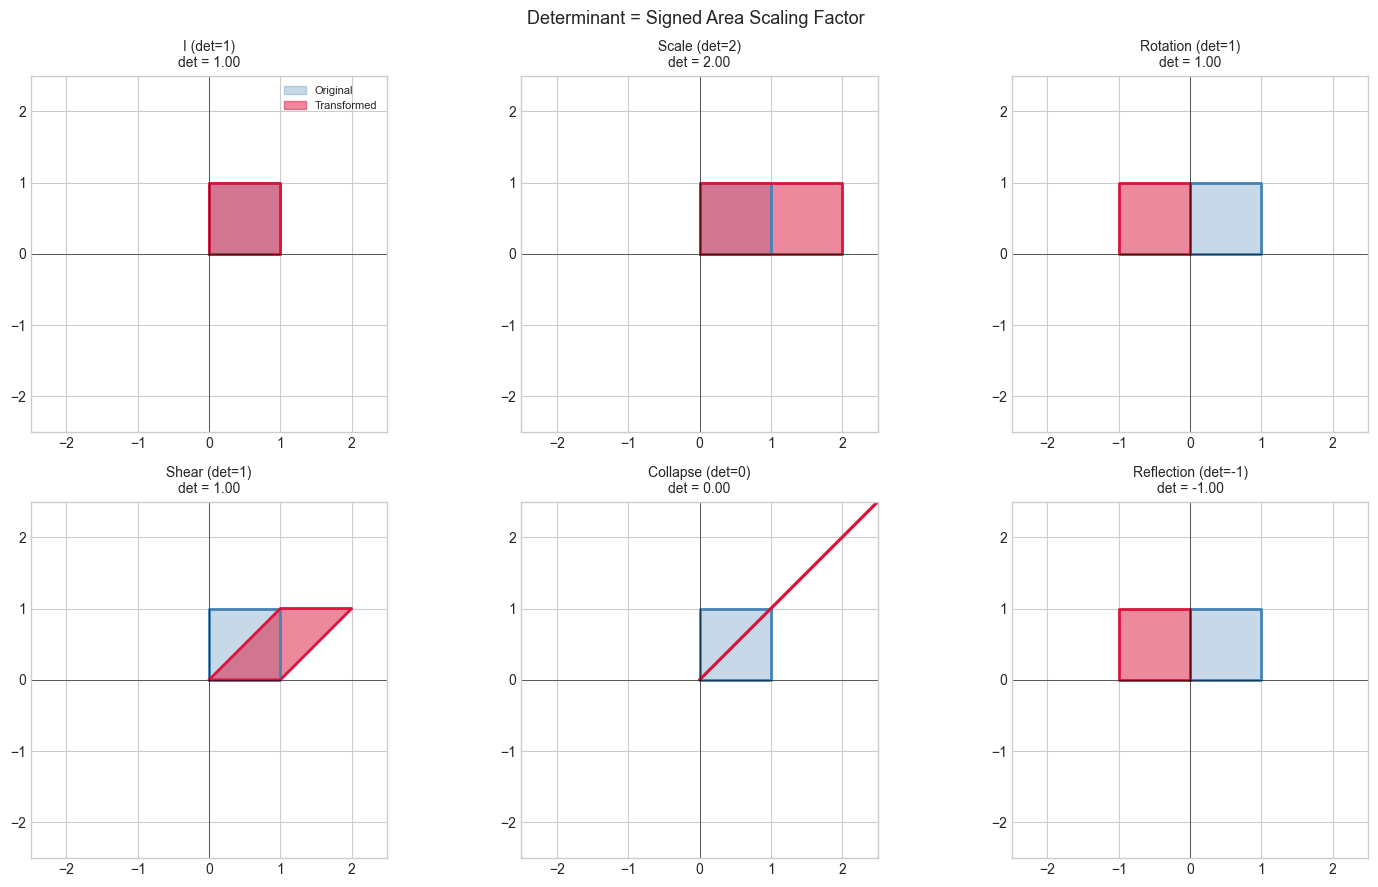

det(AB) = 0.7010
det(A)*det(B) = 0.7010
Equal: True


In [1]:
# --- Determinants: Signed area/volume scaling ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# 2D: the determinant of A = signed area of the parallelogram
# formed by the columns of A

# Start with a unit square
square = np.array([[0,1,1,0,0],[0,0,1,1,0]], dtype=float)

matrices = {
    'I (det=1)':      np.eye(2),
    'Scale (det=2)':  np.array([[2,0],[0,1]]),
    'Rotation (det=1)': np.array([[0,-1],[1,0]]),
    'Shear (det=1)':  np.array([[1,1],[0,1]]),
    'Collapse (det=0)':np.array([[1,2],[1,2]]),
    'Reflection (det=-1)': np.array([[-1,0],[0,1]]),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (title, A) in zip(axes.flat, matrices.items()):
    result = A @ square
    ax.fill(square[0], square[1], alpha=0.3, color='steelblue', label='Original')
    ax.fill(result[0], result[1], alpha=0.5, color='crimson', label='Transformed')
    ax.plot(square[0], square[1], 'steelblue', lw=2)
    ax.plot(result[0], result[1], 'crimson', lw=2)
    det_val = np.linalg.det(A)
    ax.set_title(f'{title}\ndet = {det_val:.2f}', fontsize=10)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.axhline(0,color='k',lw=0.4); ax.axvline(0,color='k',lw=0.4)

axes.flat[0].legend(fontsize=8)
plt.suptitle('Determinant = Signed Area Scaling Factor', fontsize=13)
plt.tight_layout(); plt.show()

# det(AB) = det(A) * det(B)
np.random.seed(7)
A = np.random.randn(4,4); B = np.random.randn(4,4)
print(f"det(AB) = {np.linalg.det(A@B):.4f}")
print(f"det(A)*det(B) = {np.linalg.det(A)*np.linalg.det(B):.4f}")
print(f"Equal: {np.isclose(np.linalg.det(A@B), np.linalg.det(A)*np.linalg.det(B))}")

---

## 4. Mathematical Formulation

```
For 2×2:  det([[a,b],[c,d]]) = ad - bc
  = signed area of parallelogram spanned by columns [a,c] and [b,d]

For 3×3: Sarrus' rule / cofactor expansion (see ch159)

Key properties:
  det(I) = 1                           [identity preserves volume]
  det(AB) = det(A)·det(B)              [volumes multiply under composition]
  det(Aᵀ) = det(A)                     [transpose preserves volume]
  det(αA) = αⁿ det(A)  (n×n matrix)   [scaling each entry by α scales volume by αⁿ]
  det(A⁻¹) = 1/det(A)

Geometric interpretation:
  |det(A)| = volume scaling factor of transformation A
  sign(det(A)) = orientation: positive preserves orientation,
                               negative flips it (reflection)
  det(A) = 0 ⟺ A is singular ⟺ transformation collapses a dimension
```

---

## 7. Exercises

**Easy 1.** Compute det([[3,1],[2,4]]) by hand. What does it mean geometrically?

**Easy 2.** Without computing, what is the determinant of a matrix whose two rows are identical?

**Medium 1.** Create a 2×2 matrix whose columns span a parallelogram of area exactly 5. Verify with numpy.

**Medium 2.** Show empirically that det(A²) = det(A)² for 10 random 3×3 matrices.

**Hard.** The cross product u×v (ch136) is related to a 3×3 determinant. Show this: write the cross product formula as the cofactor expansion of `det([[i,j,k],[u1,u2,u3],[v1,v2,v3]])`.

---

## 9. Chapter Summary & Connections

- `|det(A)|` = volume scaling factor; `sign(det(A))` = orientation (flip or preserve).
- `det(A)=0` ↔ A collapses space ↔ A is singular ↔ rank < n.
- `det(AB) = det(A)·det(B)` — determinants multiply under composition.

**Forward connections:**
- In ch159 (Determinants Computation), we compute the n×n determinant via cofactor expansion and LU decomposition.
- In ch169–170 (Eigenvectors/Eigenvalues), the characteristic equation `det(A - λI) = 0` is the core tool for finding eigenvalues.